In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data (2).csv")


In [3]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# HANDLING MISSING VALUES

In [4]:
categorical_col = df.select_dtypes(include = ["object"]).columns
numerical_col = df.select_dtypes(include = ["float64"]).columns

In [5]:
categorical_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [6]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[numerical_col] = num_imp.fit_transform(df[numerical_col])

In [7]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [8]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])

In [9]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA - exploratory data analysis (patterns, relations etc)

Text(0.5, 1.0, 'Is loan approved or not')

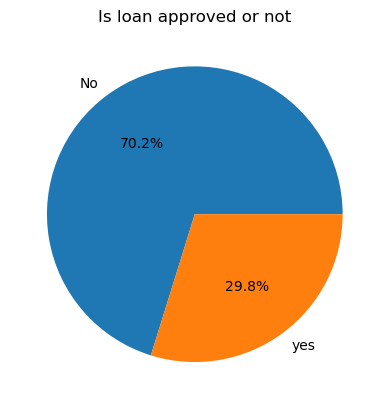

In [10]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count , labels = ["No" , "yes"] , autopct = "%1.1f%%")
plt.title("Is loan approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

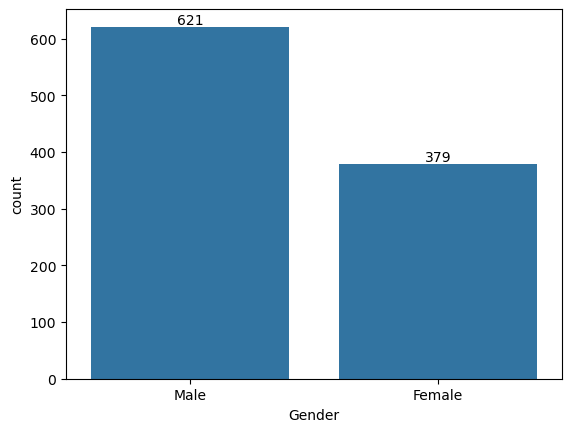

In [11]:
#analyze categories
gender_based = df["Gender"].value_counts()
# plt.pie(gender_based ,labels =["male" , "female"] , autopct = "%1.1f%%")
# plt.title("based on gender loan_approved")
ax = sns.barplot(gender_based)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

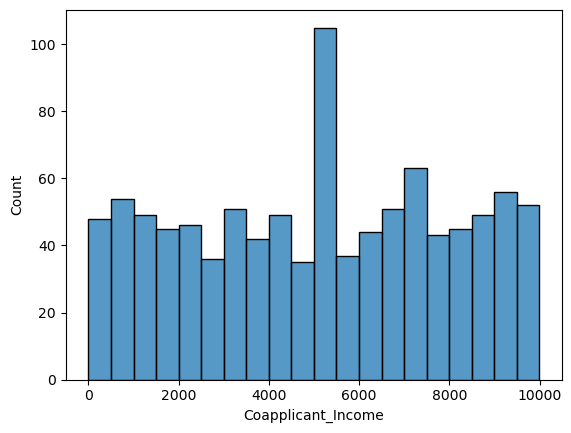

In [12]:
# analyze income

sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

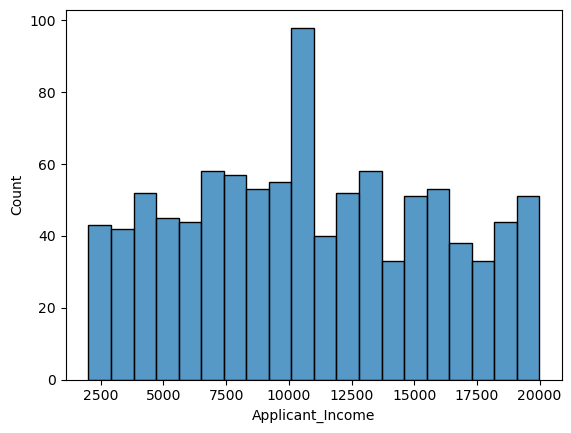

In [13]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

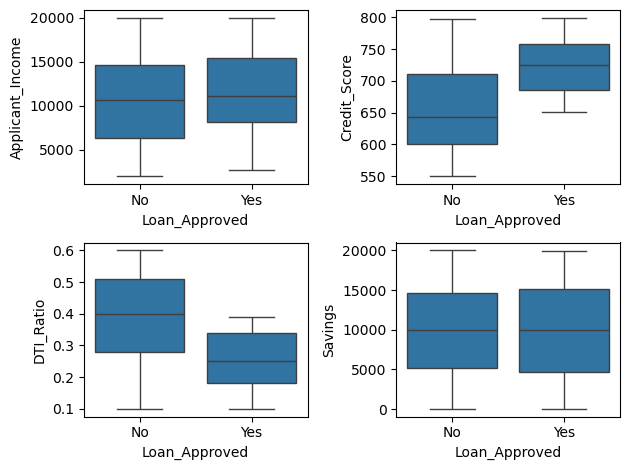

In [14]:
 # outliers - box plot
fig , axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1],data = df, x = "Loan_Approved", y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

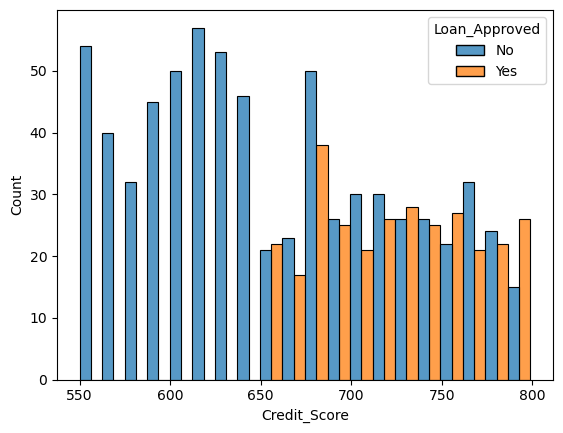

In [15]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple ="dodge"
)

In [16]:
# removing applicant id
df = df.drop("Applicant_ID" , axis = 1)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# ENCODING 


In [18]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [19]:
le = LabelEncoder()
df["Education_Level"]  = le.fit_transform(df["Education_Level"])
df["Loan_Approved"]  = le.fit_transform(df["Loan_Approved"])

df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [20]:
cols = [ "Employment_Status" , "Marital_Status" ,"Gender" , "Employer_Category" , "Loan_Approved" , "Property_Area" , "Loan_Purpose"]

ohe = OneHotEncoder( drop = "first" , sparse_output= False ,handle_unknown="ignore" )
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(cols) , index = df.index)
df = pd.concat([df.drop(columns = cols) , encoded_df] , axis =1)

In [21]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Approved_1,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


# corelation heatmap

<Axes: >

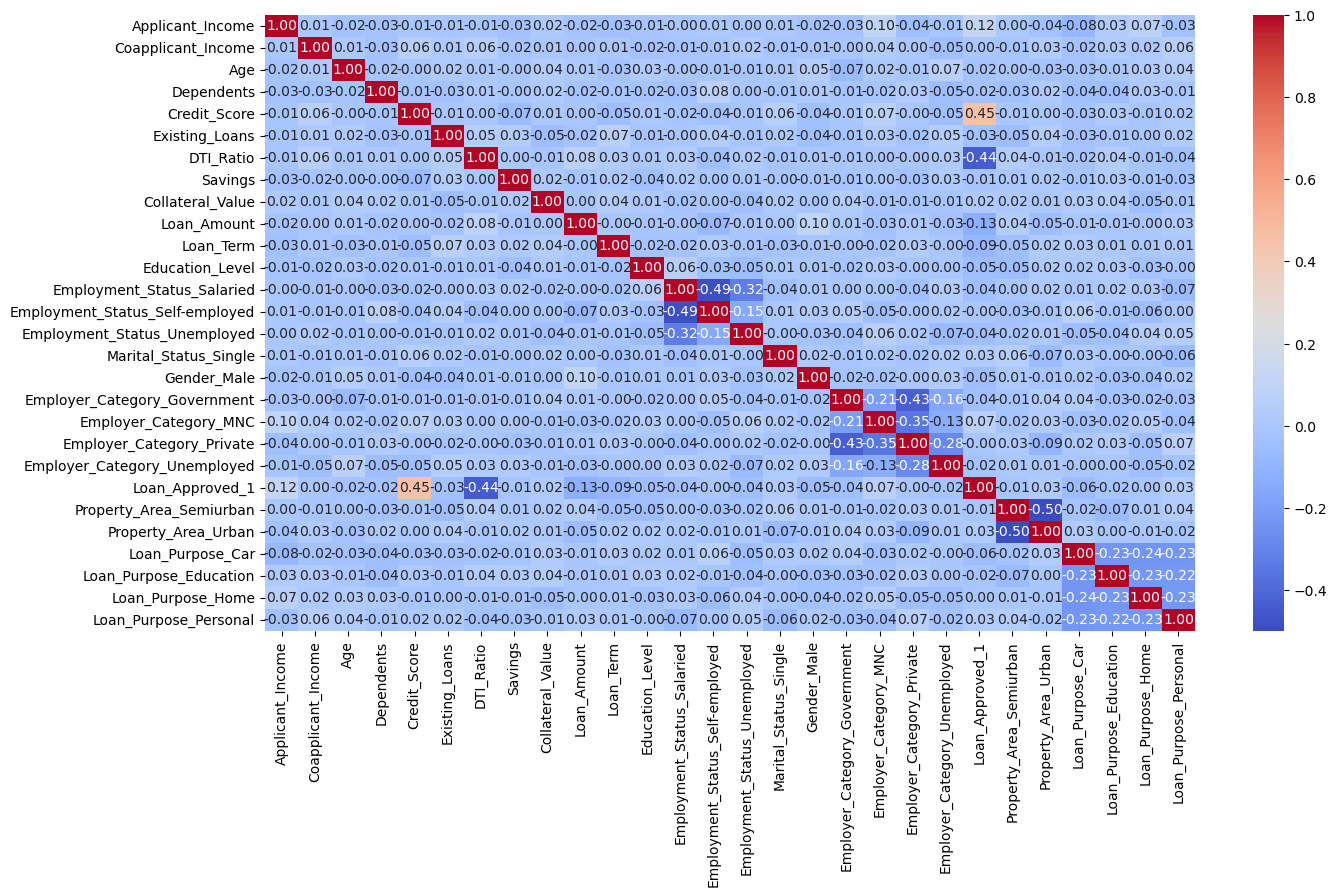

In [22]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()
plt.figure(figsize =(15,8))
sns.heatmap(
    corr_matrix ,
    annot=True,
    fmt =".2f",
    cmap = "coolwarm"
)

In [23]:
num_cols.corr()["Loan_Approved_1"].sort_values(ascending = False)
3
6+6 

12

# TRAIN-TEST-SPLIT + FEATURE SCALING

In [24]:
x = df.drop("Loan_Approved_1" , axis = 1)
y = df["Loan_Approved_1"]

In [25]:
y.head()

0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Loan_Approved_1, dtype: float64

In [26]:
x_train , x_test, y_train ,y_test = train_test_split( x ,y , random_state = 42, test_size =0.2)

In [27]:
x_train.head()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# TRAIN & EVALUATE MODELS

In [28]:
# logisic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
print("LogisticRegression")
y_pred = log_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))


LogisticRegression
precision  0.7833333333333333
acccuracy  0.865
recall  0.7704918032786885
f1   0.7768595041322314
confusion_matrix  [[126  13]
 [ 14  47]]


In [30]:
# for knn
print("KNN MODEL")
from sklearn.neighbors import KNeighborsClassifier
k_model = KNeighborsClassifier(n_neighbors = 5)
k_model.fit(x_train_scaled,y_train)
y_pred = k_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))

KNN MODEL
precision  0.6274509803921569
acccuracy  0.76
recall  0.5245901639344263
f1   0.5714285714285714
confusion_matrix  [[120  19]
 [ 29  32]]


In [ ]:
# neive bayes
from sklearn.naive_bayes import GaussianNB
neive_model = GaussianNB()
print("neive bayes MODEL")
neive_model.fit(x_train_scaled,y_train)
y_pred =neive_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))

 # based on precision score neive bayes is best

# feature engineering

In [ ]:
# ADD AND TRANSFORM FEATURES

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

x = df.drop(columns = ["Loan_Approved_1","Credit_Score" ,"DTI_Ratio", "Applicant_Income"])
y = df["Loan_Approved_1"]

#train _test _split
x_train , x_test, y_train ,y_test = train_test_split( x ,y , random_state = 42, test_size =0.2)
# scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:

print("LogisticRegression")
y_pred = log_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))

In [32]:
print("KNN MODEL")
from sklearn.neighbors import KNeighborsClassifier
k_model = KNeighborsClassifier(n_neighbors = 5)
k_model.fit(x_train_scaled,y_train)
y_pred = k_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))

KNN MODEL
precision  0.6274509803921569
acccuracy  0.76
recall  0.5245901639344263
f1   0.5714285714285714
confusion_matrix  [[120  19]
 [ 29  32]]


In [41]:
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
print("neive bayes MODEL")
naive_model.fit(x_train_scaled,y_train)
y_pred =naive_model.predict(x_test_scaled)
print("precision ", precision_score(y_test,y_pred))
print("acccuracy ", accuracy_score(y_test,y_pred))
print("recall ", recall_score(y_test,y_pred))
print("f1  ", f1_score(y_test,y_pred))
print("confusion_matrix ", confusion_matrix(y_test,y_pred))

neive bayes MODEL
precision  0.8035714285714286
acccuracy  0.865
recall  0.7377049180327869
f1   0.7692307692307693
confusion_matrix  [[128  11]
 [ 16  45]]


In [42]:
import pickle
import os

# Create folder if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# 1. Save Exact Columns sequence
with open('saved_models/features.pkl', 'wb') as f:
    pickle.dump(list(x_train.columns), f)

# 2. Save Scaler (Jo apne training me fit kiya hai, eg: scaler ya std_scaler)
with open('saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save Trained GaussianNB Model
with open('saved_models/model.pkl', 'wb') as f:
    pickle.dump(naive_model, f)

print("All artifacts saved successfully in 'saved_models/' folder!")

All artifacts saved successfully in 'saved_models/' folder!
